In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [17]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_run4/sampler_state.pkl')

In [18]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [19]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.43207499,  0.38189501,  0.37922499,  0.60759503,  0.72708499],
        [ 0.4320748 ,  0.38190481,  0.37921717,  0.60761498,  0.72707405],
        [ 0.43208215,  0.38189863,  0.37919858,  0.60762661,  0.72706736],
        ...,
        [-0.16816089,  0.16722237,  0.597887  , -0.1667173 , -0.4224067 ],
        [ 0.57699596,  0.16490745,  0.16872068,  0.05900955,  0.61563527],
        [ 0.69263928,  0.45583437,  1.10961808,  0.05793551,  0.61476143]],
       shape=(100000, 5))]

In [20]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([0.72719608, 0.72545872, 0.72516575, ...,       -inf, 0.18866089,
              -inf], shape=(100000,))]

In [21]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))

# maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))


In [22]:
maxld_pt1

array([[5.93979891, 0.9842598 , 0.55618277, 9.82410481, 0.41788778]])

In [23]:
log_density(maxld_pt1)

array([4.52291536])

In [24]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [25]:
gwf.rhostat(h_pt1)

array(5.63139043)

In [26]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(4.59789503), array(0.00503408))

In [27]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

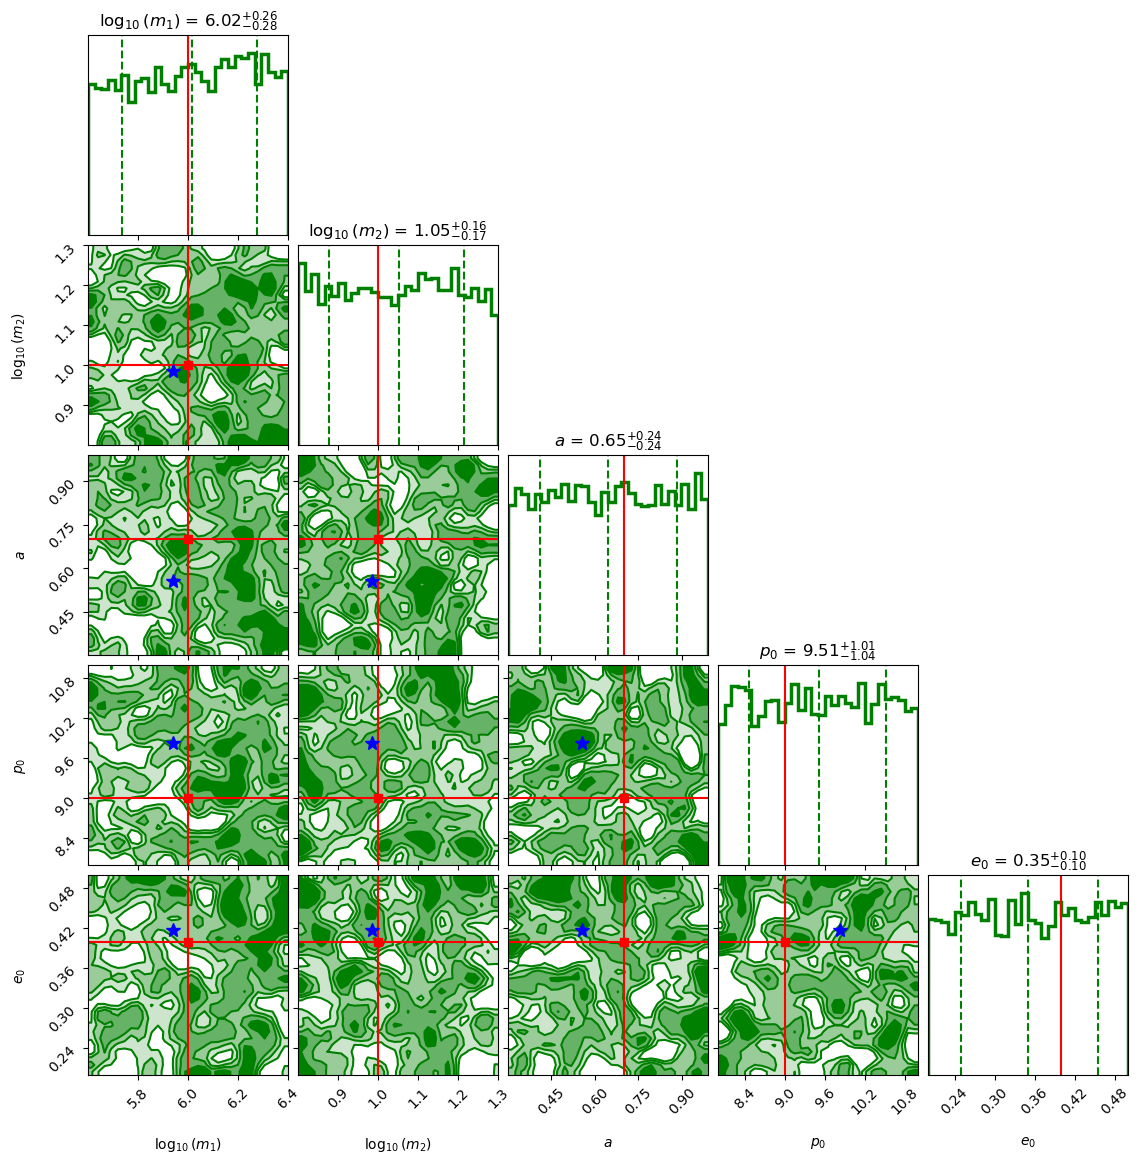

In [28]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [14]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [15]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.93979891, 0.9842598 , 0.55618277, 9.82410481, 0.41788778]])

In [31]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
# n_points = 50
# t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
# line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]

#NOTE: extended plots till it hits prior boundaries

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]



In [32]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [34]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc1

array([1.01568712, 1.06866471, 1.26817321, 1.44445057, 1.59977862,
       1.72495843, 1.79380988, 1.86785481, 1.9158805 , 1.89019238,
       2.00747049, 2.05749345, 1.99471376, 2.19557143, 2.09048458,
       2.47383116, 2.50027983, 3.63659861, 4.68723389, 4.68150368,
       3.8744889 , 3.10496497, 2.57451465, 2.5749591 , 2.66875271,
       2.70687987, 2.70654293, 2.7291664 , 2.8032437 , 2.6960356 ,
       2.94387259, 3.8803462 , 5.26757068, 5.65263342, 3.89258436,
       2.86853099, 2.65062543, 2.55080384, 2.26469432, 2.27538318,
       2.18985637, 2.08120512, 1.94600584, 1.86725566, 1.77649361,
       1.63078798, 1.50050377, 1.40815186, 1.26257858, 1.1431126 ])

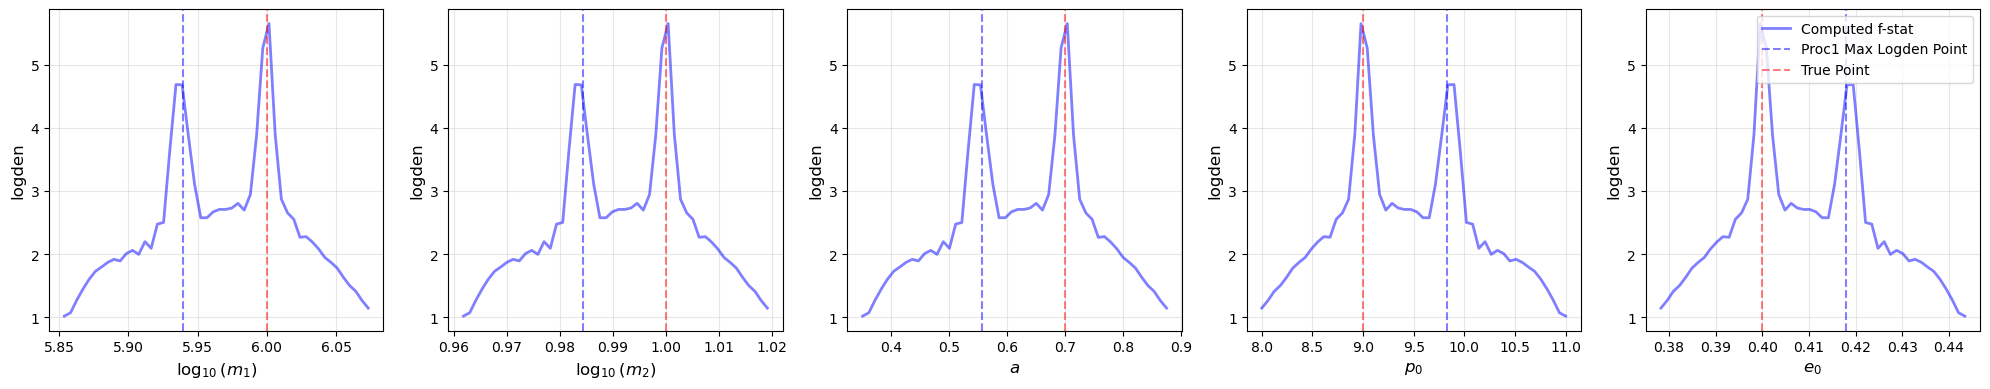

In [35]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [36]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [37]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

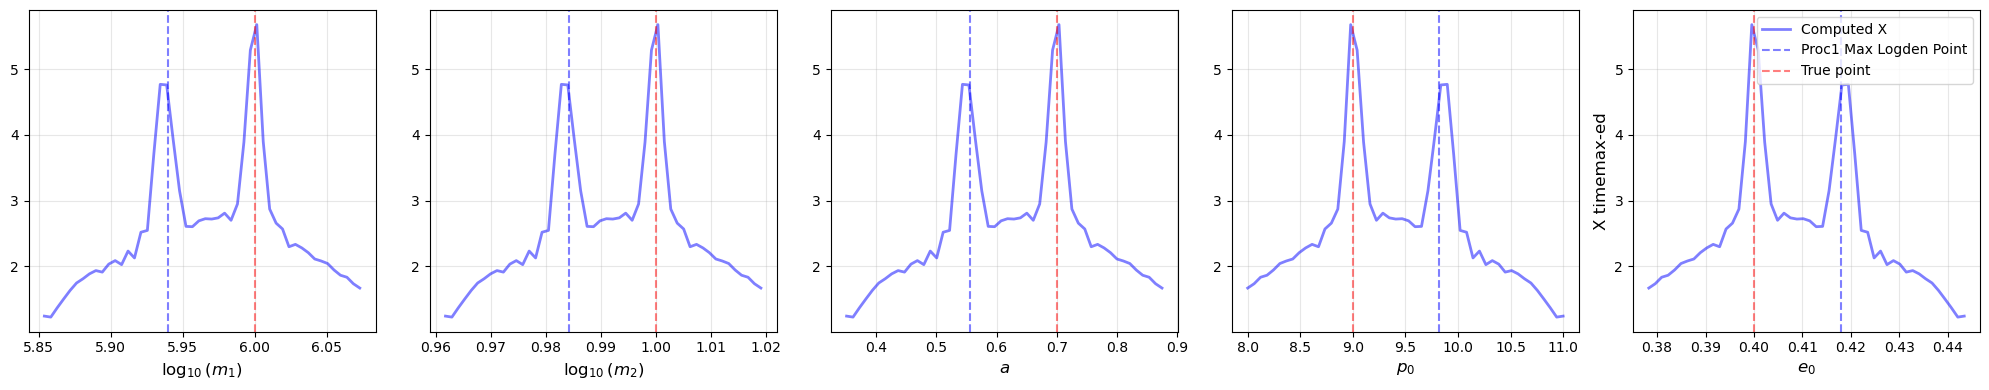

In [38]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [39]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1_nont.append(X.get())

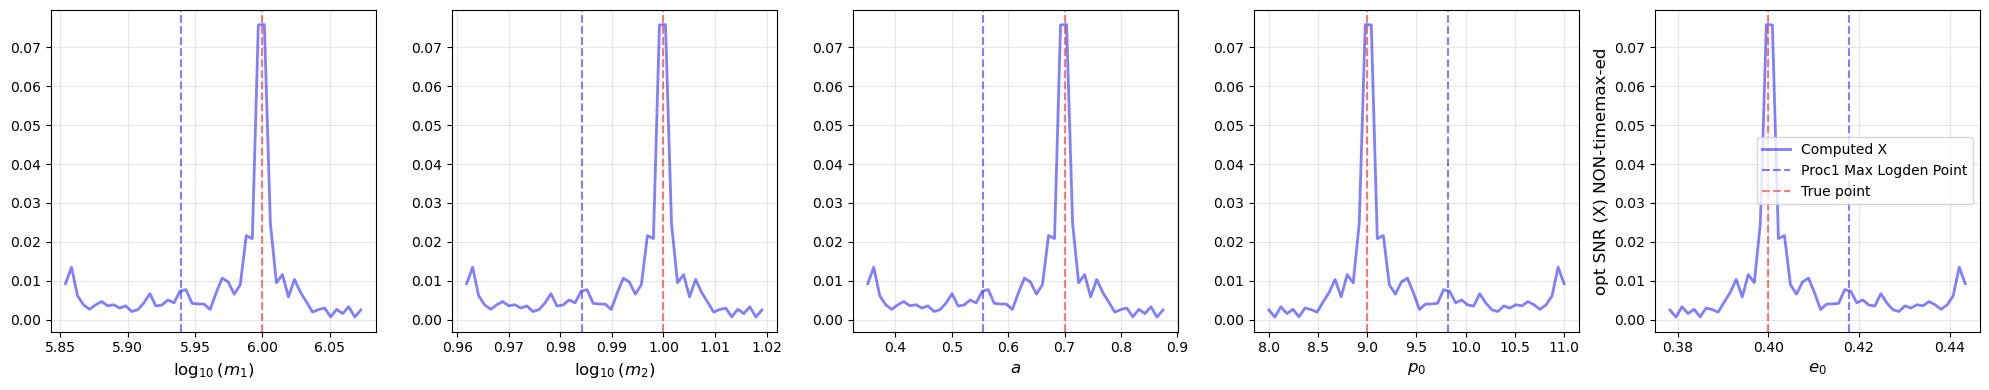

In [40]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X) NON-timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [41]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [42]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [43]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [44]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

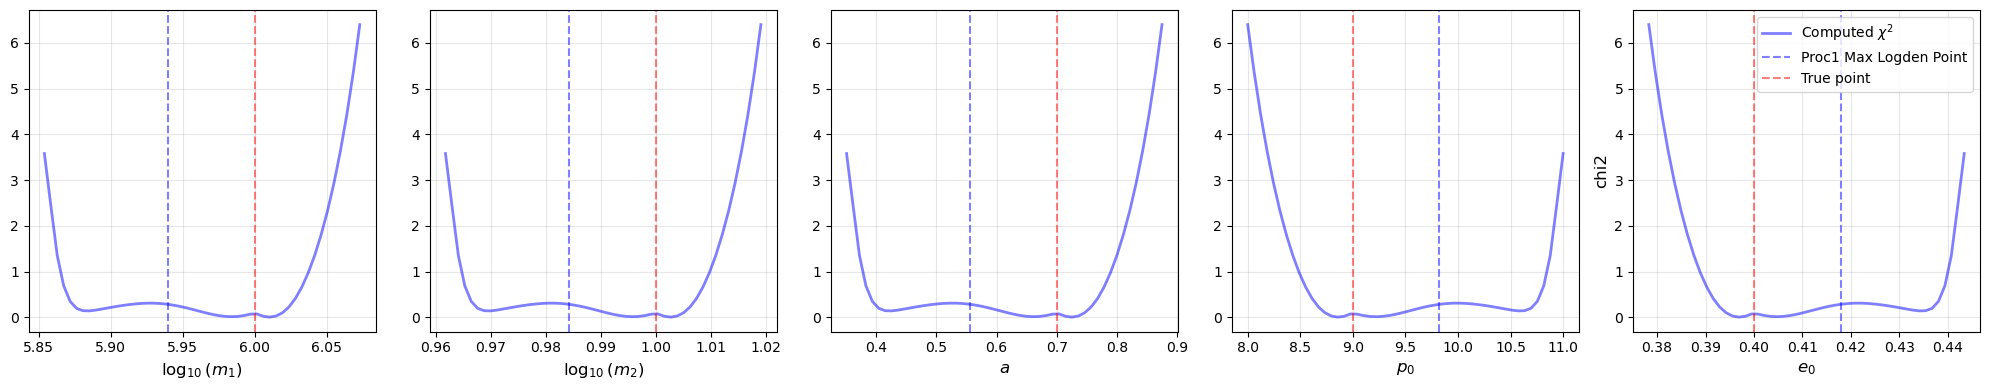

In [45]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [46]:
betas_proc1 = []
for rho_arr in rhostats_proc1:
    rho_tot = np.sqrt(np.sum(rho_arr**2))
    rho_dom_M = np.max(rho_arr)
    beta = gwf.calc_beta(rho_dom_M, rho_tot)
    betas_proc1.append(beta.get())

betas_proc1 = np.array(betas_proc1)

In [47]:
f_theory = []
for i in range(0, 50):
    f_theor = X_proc1[i] * np.exp(-0.5 * betas_proc1[i] * chi2_proc1[i])
    # print(f_theor)
    f_theory.append(f_theor)

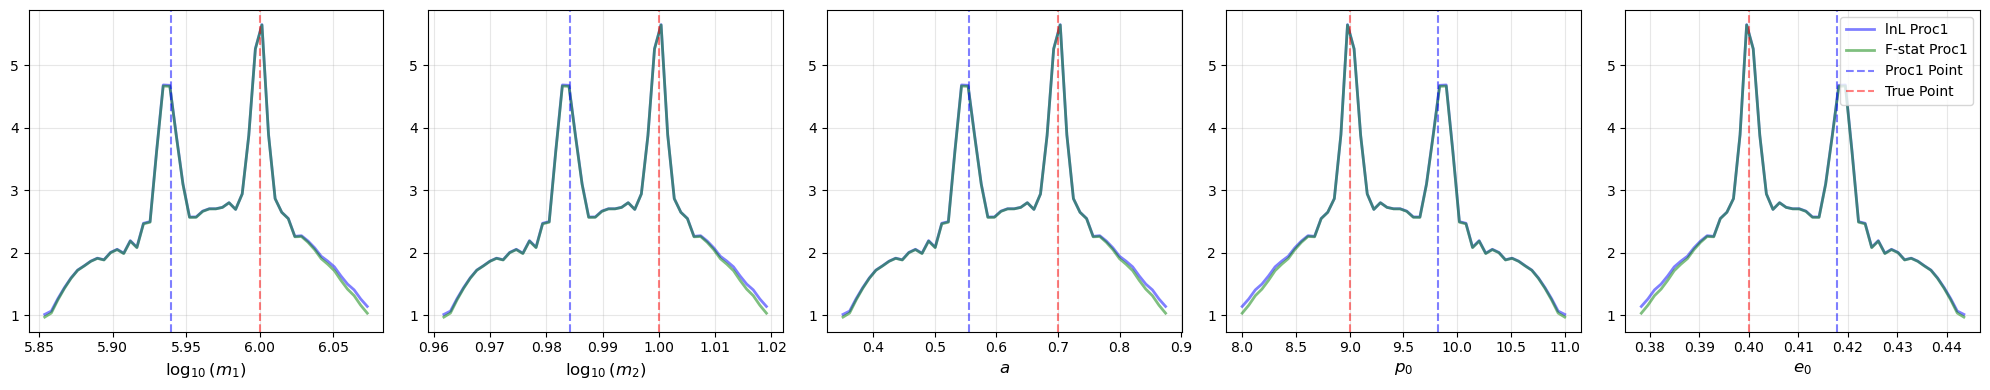

In [48]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-',
            color='blue', alpha=0.5, linewidth=2, label='lnL Proc1')
    ax.plot(line_points_proc1[dim], f_theory, '-',
            color='green', alpha=0.5, linewidth=2, label='F-stat Proc1')

    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
               alpha=0.5, label='Proc1 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--',
               alpha=0.5, label='True Point')

    ax.set_xlabel(labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()

# extended connection plots w/ first secondary

In [ ]:
i = 3  # p0

# --- Secondary 1 ---
start1     = np.array([5.87693589, 0.85550847, 0.49798554, 10.12743171, 0.48748133])
direction1 = true_pt - start1
t_lo1 = (prior_hi[i] - start1[i]) / direction1[i] if direction1[i] < 0 else (prior_lo[i] - start1[i]) / direction1[i]
t_hi1 = (prior_lo[i] - start1[i]) / direction1[i] if direction1[i] < 0 else (prior_hi[i] - start1[i]) / direction1[i]
t_vals1       = np.linspace(t_lo1, t_hi1, n_points)
line_pts1     = start1[:, np.newaxis] + t_vals1 * direction1[:, np.newaxis]
logden_p0_s1  = log_density(line_pts1.T)

# --- Secondary 2 ---
start2     = np.array([5.93979891, 0.9842598, 0.55618277, 9.82410481, 0.41788778])
direction2 = true_pt - start2
t_lo2 = (prior_hi[i] - start2[i]) / direction2[i] if direction2[i] < 0 else (prior_lo[i] - start2[i]) / direction2[i]
t_hi2 = (prior_lo[i] - start2[i]) / direction2[i] if direction2[i] < 0 else (prior_hi[i] - start2[i]) / direction2[i]
t_vals2       = np.linspace(t_lo2, t_hi2, n_points)
line_pts2     = start2[:, np.newaxis] + t_vals2 * direction2[:, np.newaxis]
logden_p0_s2  = log_density(line_pts2.T)



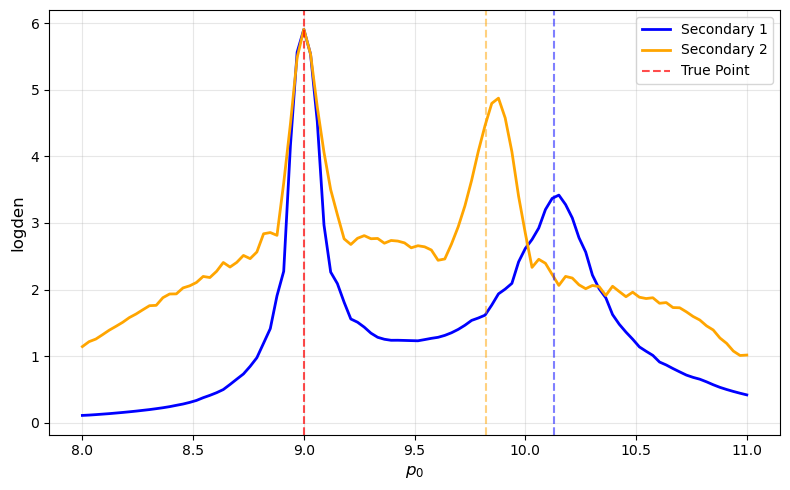

In [54]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_pts1[3], logden_p0_s1, '-', color='blue',   linewidth=2, label='Secondary 1')
ax.plot(line_pts2[3], logden_p0_s2, '-', color='orange', linewidth=2, label='Secondary 2')
ax.axvline(start1[3],      color='blue',   linestyle='--', alpha=0.5)
ax.axvline(start2[3],      color='orange', linestyle='--', alpha=0.5)
ax.axvline(param_true[3],  color='red',    linestyle='--', alpha=0.7, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()